## Exercise — Design a Mesh for the Turbulent Channel

Use what you have learned to design a proper mesh for the turbulent channel from Module 3.18.

**Given:**
- Channel half-height: $H = 0.05\,\text{m}$
- Bulk velocity: $U = 10\,\text{m/s}$
- Kinematic viscosity: $\nu = 1.5 \times 10^{-5}\,\text{m}^2/\text{s}$ (air)
- Target: $y^+ = 1$ at the first cell

**Tasks:**
1. Use `estimate_y1` to find the required $y_1$
2. Build the grid with `graded_mesh(y_1, H, N=60, ratio=1.15)`
3. Plot the $y^+$ distribution — does the first cell land at $y^+ \approx 1$?
4. Compute the expansion ratio — is it below 1.2 everywhere?

**Predict first:** With geometric clustering, will you need more or fewer total cells than the uniform $N=500$ from Module 3.18 to hit $y^+ \approx 1$?

### Estimate y1

In [74]:
U = 10
H = 0.05
L = 2*2*H
nu = 1.5 * 10**(-5)
rho = 1.2
target_y_plus = 1

Re = U * L / nu


print("Reynolds number:", Re)

C_f = 0.079 / Re**(1/4)
print("Friction coefficient:", C_f)

tau_w = C_f * 0.5 * rho * U**2
print("Wall shear stress:", tau_w)

u_tau = (tau_w / rho)**0.5
print("Friction velocity:", u_tau)

y1 = target_y_plus * nu / u_tau
print("First cell height (y1):", y1)

print("Check: ")
Re_tau = u_tau * H / nu
print("Reynolds number based on friction velocity:", Re_tau)

Reynolds number: 133333.3333333333
Friction coefficient: 0.004134208800598817
Wall shear stress: 0.248052528035929
Friction velocity: 0.45465419829793813
First cell height (y1): 3.299210709183949e-05
Check: 
Reynolds number based on friction velocity: 1515.5139943264603


### Graded Grid

In [75]:
# exponential grid stretching
import numpy as np

def exponential_grid_stretching(y1, r, N):
    y = np.zeros(N)
    y[0] = 0.0
    dy = y1
    for i in range(1, N):
        y[i] = y[i-1] + dy
        if y[i] > H:
            N = i # Update N to the actual number of points used
            break
        dy = dy * r
    return y, N

N = 60
r = 1.15
y, N = exponential_grid_stretching(y1, r, N)
y = y[:N]  # Trim the array to the actual number of points used
print("Grid points (y):", y)
print("Number of grid points:", N)

Grid points (y): [0.00000000e+00 3.29921071e-05 7.09330302e-05 1.14565092e-04
 1.64741963e-04 2.22445364e-04 2.88804276e-04 3.65117024e-04
 4.52876685e-04 5.53800295e-04 6.69862446e-04 8.03333921e-04
 9.56826116e-04 1.13334214e-03 1.33633557e-03 1.56977801e-03
 1.83823682e-03 2.14696445e-03 2.50200122e-03 2.91029351e-03
 3.37982965e-03 3.91979620e-03 4.54075774e-03 5.25486351e-03
 6.07608514e-03 7.02049002e-03 8.10655563e-03 9.35553108e-03
 1.07918529e-02 1.24436229e-02 1.43431584e-02 1.65276243e-02
 1.90397600e-02 2.19287162e-02 2.52510157e-02 2.90716602e-02
 3.34654013e-02 3.85182036e-02 4.43289262e-02]
Number of grid points: 39


### Plot y_plus distribution

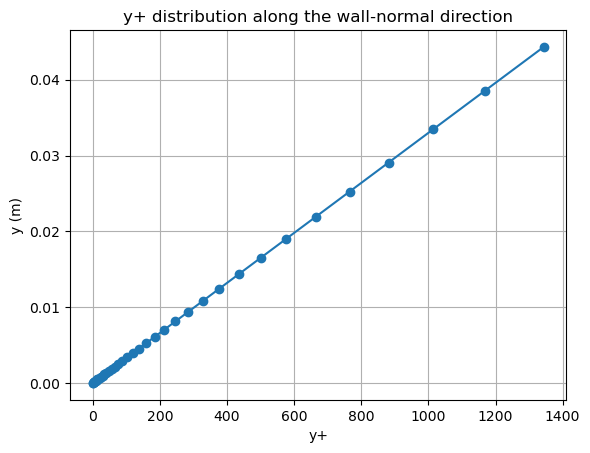

Maximum y+ value: 1343.622161233536
Minimum y+ value: 0.0
first cell y+ value: 1.0


In [76]:
# plot y plus distribution
import matplotlib.pyplot as plt
y_plus = y * u_tau / nu
plt.plot(y_plus, y, marker='o')
plt.xlabel('y+')
plt.ylabel('y (m)')
plt.title('y+ distribution along the wall-normal direction')
plt.grid()
plt.show()

print("Maximum y+ value:", np.max(y_plus))
print("Minimum y+ value:", np.min(y_plus))
print("first cell y+ value:", y_plus[1])

### Check the expansion ration of all the cell

In [77]:
# check expansion ratio of the grid
for i in range(1, N-1):
    expansion_ratio = (y[i+1] - y[i]) / (y[i] - y[i-1])
    print(f"Expansion ratio between cell {i} and {i+1}: {expansion_ratio:.2f}")

Expansion ratio between cell 1 and 2: 1.15
Expansion ratio between cell 2 and 3: 1.15
Expansion ratio between cell 3 and 4: 1.15
Expansion ratio between cell 4 and 5: 1.15
Expansion ratio between cell 5 and 6: 1.15
Expansion ratio between cell 6 and 7: 1.15
Expansion ratio between cell 7 and 8: 1.15
Expansion ratio between cell 8 and 9: 1.15
Expansion ratio between cell 9 and 10: 1.15
Expansion ratio between cell 10 and 11: 1.15
Expansion ratio between cell 11 and 12: 1.15
Expansion ratio between cell 12 and 13: 1.15
Expansion ratio between cell 13 and 14: 1.15
Expansion ratio between cell 14 and 15: 1.15
Expansion ratio between cell 15 and 16: 1.15
Expansion ratio between cell 16 and 17: 1.15
Expansion ratio between cell 17 and 18: 1.15
Expansion ratio between cell 18 and 19: 1.15
Expansion ratio between cell 19 and 20: 1.15
Expansion ratio between cell 20 and 21: 1.15
Expansion ratio between cell 21 and 22: 1.15
Expansion ratio between cell 22 and 23: 1.15
Expansion ratio between cel